--- Dataset Information ---
Cleaned Shape: (2615, 9)

--- Dataset Head ---
      OrderID  CustomerID                           ProductName  \
0  REC-861088        6120                                 Perly   
1  REC-900952       12550                  Prince Goût Chocolat   
2  REC-595965        6705  Excellence Noir Prodigieux 90% Cacao   
3  REC-942653        8645                                 Tonik   
4  REC-885998       14430                                Sésame   

                    Brand Raw_Weight  \
0                   Perly      100 g   
1                      LU      300 g   
2  Lindt EXCELLENCE,Lindt       100g   
3                    عربي       22 g   
4                  Gerblé       230g   

                                             Country  OrderDate  UnitPrice  \
0                              Morocco,United States 2024-02-22      13.18   
1  Algeria,Belgium,France,French Polynesia,German... 2024-11-13       1.50   
2  Argelia,Austria,Bélgica,Bulgaria,Canadá,Repú

C:\Users\muska\AppData\Local\Temp\ipykernel_17128\140711728.py:70: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_time = df_cleaned.set_index('OrderDate').resample('M').size().reset_index()


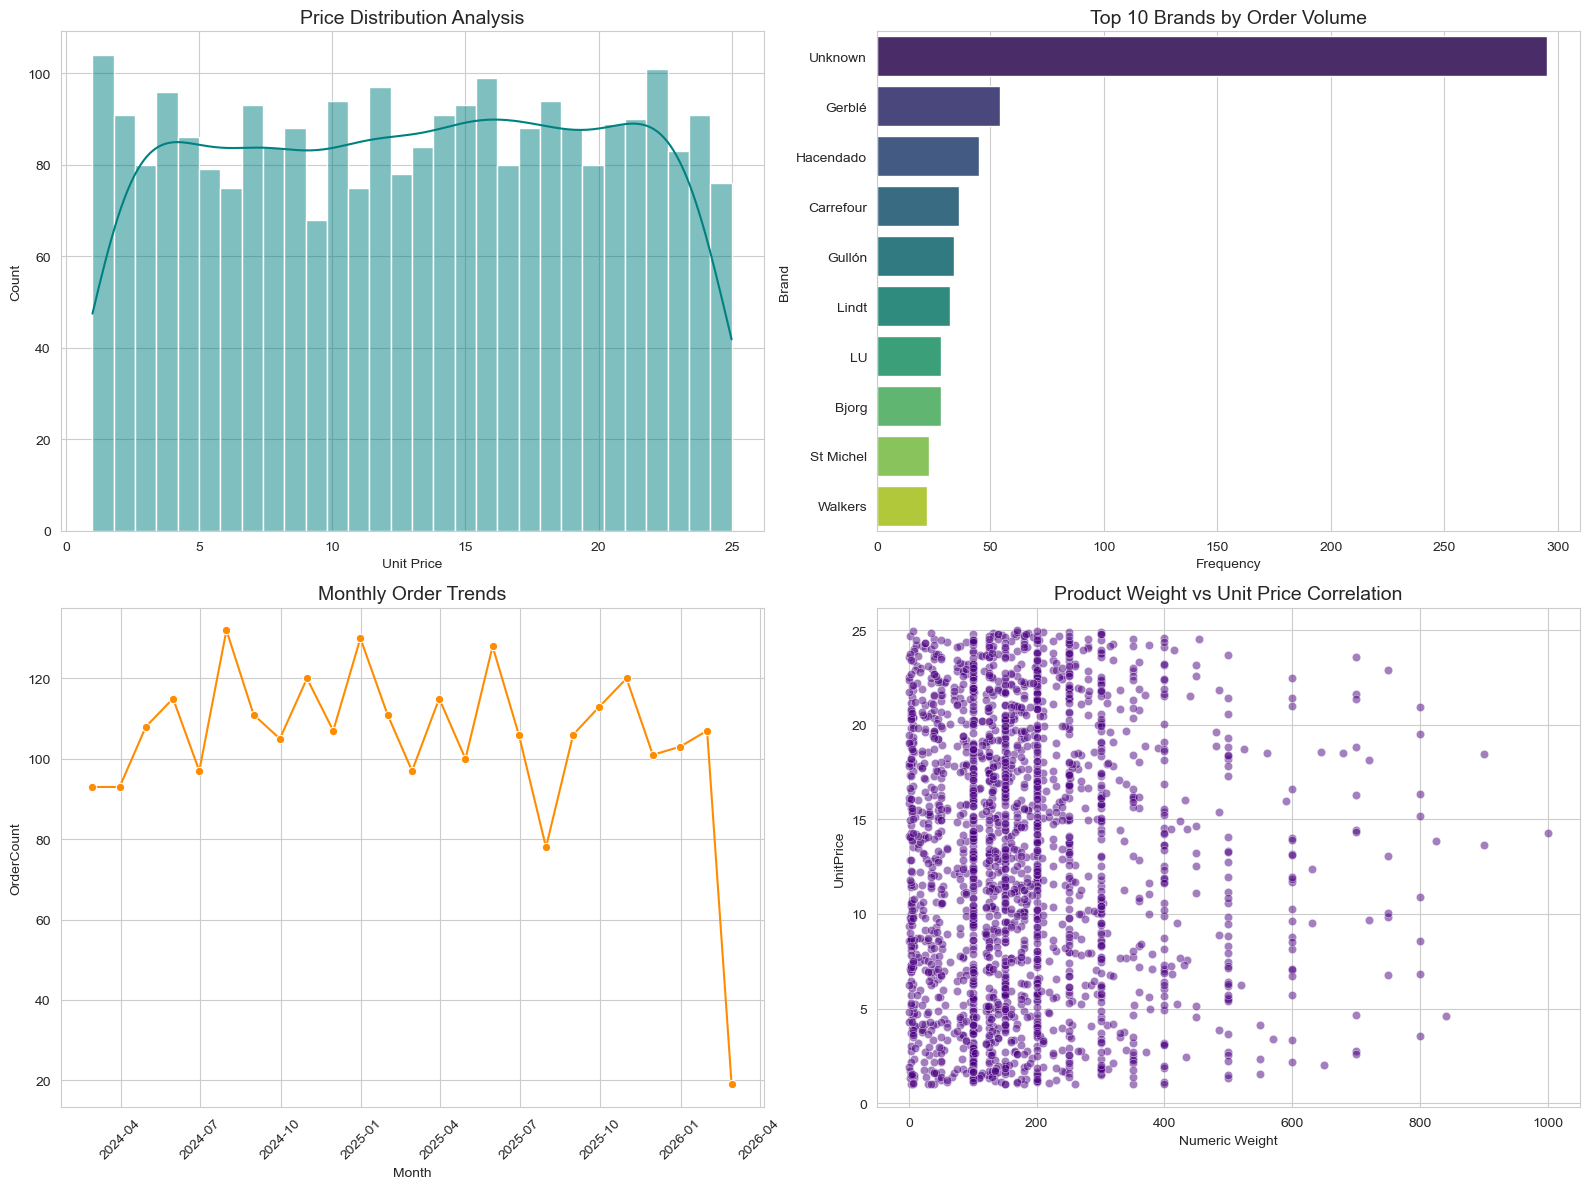


--- Cleaned Data Sample ---
         OrderID  CustomerID                                 ProductName  \
2330  REC-961684        5886                       Orange Dark Chocolate   
488   REC-350428        7250                   Protein Peanut Butter Bar   
2972  REC-833811       14931                                   Toblerone   
1990  REC-705267        7516     Galleta crocant con copos de avena zero   
393   REC-323617        8422  Excellence Noir Caramel à la pointe de sel   

                   Brand Raw_Weight                                 Country  \
2330        Tesco Finest       100g                          United Kingdom   
488                 N?kd    45 gram  France, United Kingdom, en:switzerland   
2972  Toblerone,Mondélez       35 g       Bolivia,Bulgaria,Francia,Alemania   
1990              Gullón      280 g             Portugal, Spain, en:morocco   
393                Lindt      100 g                                  France   

      OrderDate  UnitPrice  Weight_Nume

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset using the predefined DATA_DIR variable
# We assume DATA_DIR is provided as a string path in the environment
df = pd.read_csv('online_retail_real_world.csv')

# --- ETL: Data Cleaning and Type Casting ---

# Handle missing values in categorical columns to avoid plotting issues
df['Brand'] = df['Brand'].fillna('Unknown')
df['ProductName'] = df['ProductName'].fillna('Unknown')
df['Country'] = df['Country'].fillna('Unknown')

# Safe conversion of OrderDate to datetime objects
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')

# Safe conversion of UnitPrice to numeric, coercing errors to NaN
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce')

# Extract numeric weight from Raw_Weight column (e.g., '150 g' or '230g' -> 150.0)
# Uses a safe regex extraction for basic numeric patterns
df['Weight_Numeric'] = df['Raw_Weight'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

# Drop rows with critical missing values after conversion to maintain analysis integrity
df_cleaned = df.dropna(subset=['OrderDate', 'UnitPrice']).copy()

# --- EDA: Descriptive Statistics and Data Overview ---

print("--- Dataset Information ---")
print(f"Cleaned Shape: {df_cleaned.shape}")
print("\n--- Dataset Head ---")
print(df_cleaned.head())

print("\n--- Descriptive Statistics (Numeric) ---")
# describe() without datetime_is_numeric to ensure compatibility with older pandas versions
print(df_cleaned.describe())

print("\n--- Top 5 Brands by Order Count ---")
print(df_cleaned['Brand'].value_counts().head(5))

# --- Visualization: Kaggle-Safe Seaborn/Matplotlib Configuration ---

# Set general plot styling
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Distribution of Unit Price
sns.histplot(df_cleaned['UnitPrice'], bins=30, kde=True, color='teal', ax=axes[0, 0])
axes[0, 0].set_title('Price Distribution Analysis', fontsize=14)
axes[0, 0].set_xlabel('Unit Price')

# Plot 2: Top 10 Brands (Strict adherence to hue/legend stability rules)
brand_stats = df_cleaned['Brand'].value_counts().nlargest(10).reset_index()
brand_stats.columns = ['Brand', 'Frequency']
sns.barplot(
    data=brand_stats, 
    x='Frequency', 
    y='Brand', 
    hue='Brand', 
    palette='viridis', 
    legend=False, 
    ax=axes[0, 1]
)
axes[0, 1].set_title('Top 10 Brands by Order Volume', fontsize=14)

# Plot 3: Time-Series Order Trends (Monthly Resampling)
# Resampling requires a DatetimeIndex
df_time = df_cleaned.set_index('OrderDate').resample('M').size().reset_index()
df_time.columns = ['Month', 'OrderCount']
sns.lineplot(data=df_time, x='Month', y='OrderCount', marker='o', color='darkorange', ax=axes[1, 0])
axes[1, 0].set_title('Monthly Order Trends', fontsize=14)
plt.setp(axes[1, 0].get_xticklabels(), rotation=45)

# Plot 4: Weight vs Unit Price Relationship
sns.scatterplot(
    data=df_cleaned, 
    x='Weight_Numeric', 
    y='UnitPrice', 
    alpha=0.5, 
    color='indigo', 
    ax=axes[1, 1]
)
axes[1, 1].set_title('Product Weight vs Unit Price Correlation', fontsize=14)
axes[1, 1].set_xlabel('Numeric Weight')

plt.tight_layout()
plt.savefig('retail_eda_report.png')
plt.show()

# Final safe display of sample data
print("\n--- Cleaned Data Sample ---")
print(df_cleaned.sample(min(5, len(df_cleaned))))


# Exporting the new cleaned data into CSV file
df_cleaned.to_csv('cleaned_retail_data.csv')
